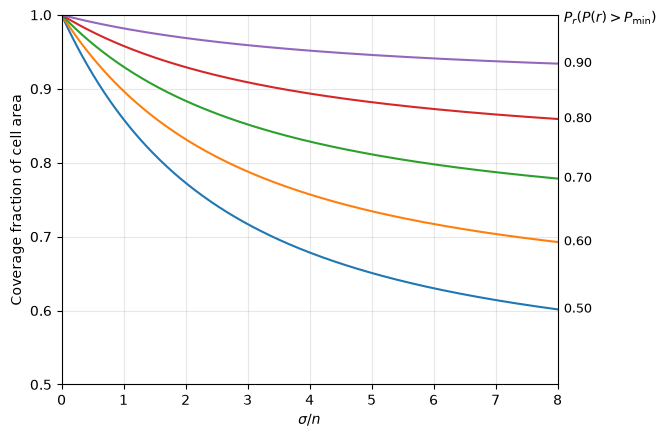

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

edge_probs = np.arange(0.5, 1.0, 0.1)
sigma_over_n = np.linspace(0.01, 8, 500)
b = 10*np.log10(np.e) / sigma_over_n

for p_edge in edge_probs:

    a = norm.isf(p_edge)  # Q^{-1}(p_edge)
   
    # Goldsmith Eq. (2.60)
    C = (
        p_edge +
        np.exp((2 - 2 * a * b) / b**2)
        * norm.sf((2 - a * b) / b)
    )

    plt.plot(
        sigma_over_n,
        C,
    )
    plt.text(
    sigma_over_n[-1] + 0.1,
    C[-1],
    f"{p_edge:.2f}",
    va="center",
    fontsize=9,
    )
plt.xlabel(r'$\sigma/n$')
plt.ylabel("Coverage fraction of cell area")
plt.xlim(0, 8)
plt.ylim(0.5, 1.0)

plt.text(8.1, 0.99, r"$P_r(P(r)>P_{\mathrm{min}})$")

plt.grid(True, alpha=0.3)
plt.show()


$$
\begin{align}
P_{cov}(r) &= Q\left(\frac{P_{min}-P_r(r)}{\sigma}\right) \\
a &= Q^{-1}(P_{cov}(R)) 
\end{align}
$$
For a normalized position $x=r/R$, where $R$ is edge radius and $r$ is a given radii

$$
P_{cov}(r)=Q \left( a - \frac{10 n \log_{10}(1/x)}{\sigma} \right)
$$

In [56]:
from numpy.typing import NDArray

_N_NODES = 5

def coverage_prob(positions: NDArray[np.float64], edge_prob=0.60, sigma=8.0, pathloss_exponent=2.0):
    """Returns the coverage probability from an array of positions normalized relative to the edge radius"""
    positions = np.asarray(positions)
    a = norm.isf(edge_prob)
    margin = 10 * pathloss_exponent * np.log10(1 / positions)

    return norm.sf(a - margin / sigma)

radial_coverage = coverage_prob(np.linspace(0.1, 1.0, _N_NODES))
edge_coverage = coverage_prob(np.ones(_N_NODES))

print(radial_coverage)
print(edge_coverage)

# Random pull from Bernoulli distribution
bernoulli_trial = np.random.binomial(n=1, p=edge_coverage, size=_N_NODES)
print(bernoulli_trial)

[0.99705053 0.92971055 0.81658851 0.70197622 0.6       ]
[0.6 0.6 0.6 0.6 0.6]
[1 0 1 1 1]
